# C.1 & C.2 — Joinability Analysis

**Member C deliverable** for the NYC Open Data project.

This notebook implements instance-level joinability detection across 2,391 NYC Socrata datasets using two complementary methods:

- **C.1 — Lazo (MinHash)**: finds columns with overlapping *value domains* using MinHash signatures and LSH indexing. Catches joins that name-based methods (Members A and B) miss entirely — e.g. `boro` vs `borough` where both contain the same 5 NYC borough names.
- **C.2 — LLM Schema Mapping**: takes a sample of Lazo candidates and asks an LLM to judge whether each pair refers to the same real-world concept. Catches false positives that Lazo can't resolve from values alone (e.g. two columns both containing `[yes, na, no]` but for unrelated survey questions).

**Outputs:**
- `lazo_candidates.parquet` — all column pairs with containment score ≥ 0.5
- `llm_candidates.parquet` — LLM yes/no judgment on a stratified sample of 500 pairs


## Setup

In [3]:
import json
import random
import os
import pandas as pd
import matplotlib.pyplot as plt
import requests
import anthropic
from dotenv import load_dotenv
from datasketch import MinHash, MinHashLSH
from tqdm import tqdm

load_dotenv()
client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
print("ready")


ready


## Load Data

In [5]:
with open('../../Data/nyc_socrata_datasets.json', 'r') as f:
    data = json.load(f)

# basic stats
total_cols = sum(len(d['columns']) for d in data)
missing_samples = sum(1 for d in data if not d.get('sample_rows'))

print(f"datasets: {len(data)}")
print(f"total columns: {total_cols}")
print(f"avg columns per dataset: {total_cols / len(data):.1f}")
print(f"datasets missing sample rows: {missing_samples} (skipped)")


datasets: 2391
total columns: 56679
avg columns per dataset: 23.7
datasets missing sample rows: 5 (skipped)


## C.1 — Lazo (MinHash-based Joinability)

### Column Filtering

We filter columns to a viable range for MinHash:
- **Too few unique values (= 1)**: constants, useless for joins
- **Too many unique values (= 100)**: likely IDs or free-text, won't overlap meaningfully across datasets
- **Purely numeric**: small integers like `{1,2,3,4,5}` appear in completely unrelated columns (age categories, district numbers, survey codes) and generate massive false positives

We keep columns with **2–50 unique non-numeric values**.


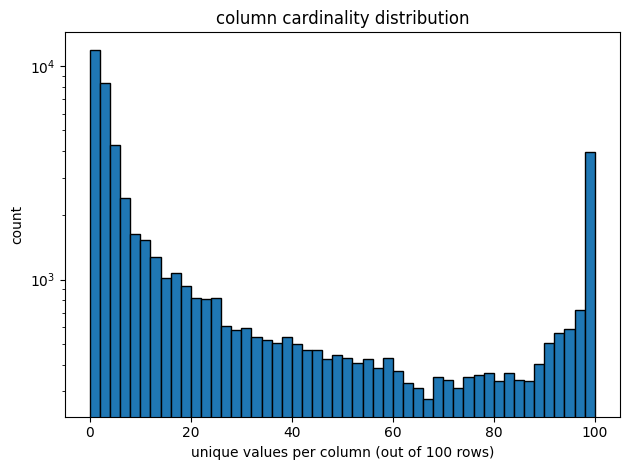

total columns: 56610
viable columns after filtering: 16681
filtered out: 39929 (70.5%)


In [7]:
def get_column_values(dataset, col_name):
    """extract unique string values for a column from sample rows"""
    rows = dataset.get('sample_rows') or []
    return list(set(str(r[col_name]) for r in rows if col_name in r and r[col_name] is not None))

def is_purely_numeric(values):
    """return true if all values can be parsed as floats"""
    try:
        [float(v) for v in values]
        return True
    except:
        return False

def get_viable_column_values(dataset, col_name, min_card=2, max_card=50):
    """return values for a column if it passes cardinality and type filters, else None"""
    values = get_column_values(dataset, col_name)
    if not (min_card <= len(values) <= max_card):
        return None
    if is_purely_numeric(values):
        return None
    return values

# show cardinality distribution
cardinalities = []
for d in data:
    if not d.get('sample_rows'):
        continue
    for col in d['columns']:
        cardinalities.append(len(get_column_values(d, col)))

plt.hist(cardinalities, bins=50, edgecolor='black')
plt.xlabel('unique values per column (out of 100 rows)')
plt.ylabel('count')
plt.title('column cardinality distribution')
plt.yscale('log')
plt.tight_layout()
plt.show()

viable = sum(
    1 for d in data if d.get('sample_rows')
    for col in d['columns']
    if get_viable_column_values(d, col) is not None
)
print(f"total columns: {len(cardinalities)}")
print(f"viable columns after filtering: {viable}")
print(f"filtered out: {len(cardinalities) - viable} ({(len(cardinalities) - viable) / len(cardinalities) * 100:.1f}%)")


### Build MinHash Signatures

Each viable column is hashed into a compact 128-permutation MinHash signature representing its set of values.


In [8]:
def make_minhash(values, num_perm=128):
    """build a minhash signature from a list of string values"""
    m = MinHash(num_perm=num_perm)
    for v in values:
        m.update(str(v).lower().encode('utf8'))
    return m

# build signatures for all viable columns
column_signatures = []
for d in data:
    if not d.get('sample_rows'):
        continue
    for col in d['columns']:
        values = get_viable_column_values(d, col)
        if values is not None:
            m = make_minhash(values)
            column_signatures.append((d['id'], d['name'], col, m))

print(f"signatures built: {len(column_signatures)}")


signatures built: 16681


### Build LSH Index and Find Candidate Pairs

We use Locality Sensitive Hashing (LSH) to efficiently find column pairs with similar signatures, avoiding a brute-force O(n²) comparison across all 16k columns.

We compute **containment** (asymmetric) rather than Jaccard:

`containment(A→B) = |A ∩ B| / |A|`

This is more appropriate than Jaccard when one column covers a subset of another's domain — e.g. a dataset covering only 3 boroughs vs one covering all 5.

We take the **max** of both directions and require:
- Score ≥ 0.5
- At least 3 distinct values in common (guards against trivially small sets like `[yes, no]`)


In [11]:
# build fast lookup dicts
sig_lookup = {}
val_lookup = {}

dataset_index = {d['id']: d for d in data}

for dataset_id, dataset_name, col_name, m in column_signatures:
    key = f"{dataset_id}::{col_name}"
    sig_lookup[key] = m
    val_lookup[key] = set(
        str(v).lower()
        for v in get_column_values(dataset_index[dataset_id], col_name)
        if v is not None
    )

# build lsh index at threshold=0.5
lsh = MinHashLSH(threshold=0.3, num_perm=128)
for key, m in sig_lookup.items():
    lsh.insert(key, m)

print("lsh index built")


lsh index built


In [13]:
# query lsh and compute containment scores
results = []
seen_pairs = set()

for key_a, vals_a in tqdm(val_lookup.items()):
    candidates = lsh.query(sig_lookup[key_a])

    for key_b in candidates:
        if key_a == key_b:
            continue
        pair = tuple(sorted([key_a, key_b]))
        if pair in seen_pairs:
            continue
        seen_pairs.add(pair)

        vals_b = val_lookup[key_b]
        overlap = vals_a & vals_b

        # require at least 3 distinct shared values
        if len(overlap) < 3:
            continue

        containment_ab = len(overlap) / len(vals_a) if vals_a else 0
        containment_ba = len(overlap) / len(vals_b) if vals_b else 0
        score = max(containment_ab, containment_ba)

        if score >= 0.3:
            did_a, col_a = key_a.split("::", 1)
            did_b, col_b = key_b.split("::", 1)
            results.append({
                "dataset_id_1": did_a,
                "column_name_1": col_a,
                "dataset_id_2": did_b,
                "column_name_2": col_b,
                "score": round(score, 4),
                "method": "lazo"
            })

print(f"candidate pairs found: {len(results)}")


100%|██████████| 16681/16681 [00:03<00:00, 4192.88it/s]

candidate pairs found: 430144


### Score Distribution and Quality Check

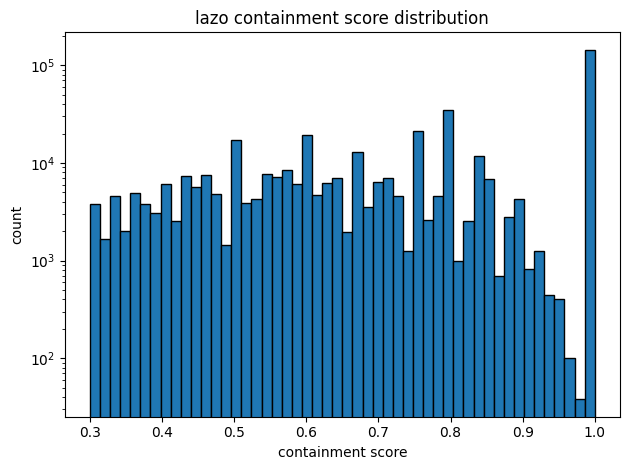

score >= 0.9: 148984
score >= 0.8: 211602
score >= 0.7: 257437
score >= 0.5: 370801

--- sample pairs ---

agency <-> agency_acronym (score=0.5714)
  A: ['dot', 'dohmh', 'nypd', 'dpr', 'dsny', 'oos']
  B: ['nycers', 'dvs', 'nycem', 'cuny', 'cwp', 'cchr']

address_borough <-> city (score=0.8333)
  A: ['brooklyn', 'staten island', 'queens', 'outside nyc', 'manhattan', 'bronx']
  B: ['brooklyn', 'jackson heights', 'new york', 'new hyde park', 'forest hills', 'ozone park']

qr_4_2 <-> qr_1_2 (score=1.0)
  A: ['well developed', 'proficient', 'no data', 'developing']
  B: ['well developed', 'proficient', 'no data', 'developing']

borough <-> boro (score=1.0)
  A: ['brooklyn', 'staten is', 'queens', 'manhattan', 'bronx']
  B: ['queens', 'manhattan', 'bronx', 'brooklyn']

park_borough <-> city (score=1.0)
  A: ['brooklyn', 'staten island', 'queens', 'manhattan', 'bronx']
  B: ['brooklyn', 'manhattan', 'queens']


In [14]:
scores = [r['score'] for r in results]

plt.hist(scores, bins=50, edgecolor='black')
plt.xlabel('containment score')
plt.ylabel('count')
plt.title('lazo containment score distribution')
plt.yscale('log')
plt.tight_layout()
plt.show()

print(f"score >= 0.9: {sum(1 for s in scores if s >= 0.9)}")
print(f"score >= 0.8: {sum(1 for s in scores if s >= 0.8)}")
print(f"score >= 0.7: {sum(1 for s in scores if s >= 0.7)}")
print(f"score >= 0.5: {sum(1 for s in scores if s >= 0.5)}")

# sanity check -- sample 5 pairs
print("\n--- sample pairs ---")
for r in random.sample(results, 5):
    key_a = f"{r['dataset_id_1']}::{r['column_name_1']}"
    key_b = f"{r['dataset_id_2']}::{r['column_name_2']}"
    print(f"\n{r['column_name_1']} <-> {r['column_name_2']} (score={r['score']})")
    print(f"  A: {list(val_lookup[key_a])[:6]}")
    print(f"  B: {list(val_lookup[key_b])[:6]}")


### Save C.1 Output

In [15]:
df_lazo = pd.DataFrame(results)
df_lazo.to_parquet("lazo_candidates.parquet", index=False)

print(f"saved {len(df_lazo)} pairs to lazo_candidates.parquet")
print(df_lazo.head())
print(df_lazo.describe())


saved 430144 pairs to lazo_candidates.parquet
  dataset_id_1          column_name_1 dataset_id_2  \
0    8wbx-tsch  base_telephone_number    yhuu-4pt3   
1    vx8i-nprf                     mi    cvh6-nmyi   
2    vx8i-nprf                     mi    4y63-yw9e   
3    vx8i-nprf                     mi    e555-uc5w   
4    vx8i-nprf                     mi    kgzj-pjna   

                    column_name_2   score method  
0           base_telephone_number  0.5882   lazo  
1  _2010_11_progress_report_grade  0.8000   lazo  
2      _2012_2013_progress_report  0.6667   lazo  
3               environment_grade  0.8000   lazo  
4                       boroughcd  0.4286   lazo  
               score
count  430144.000000
mean        0.754841
std         0.216358
min         0.300000
25%         0.578900
50%         0.777800
75%         1.000000
max         1.000000


## C.2 — LLM Schema Mapping

Lazo finds columns with overlapping values but can't distinguish meaningful joins from coincidental overlaps — e.g. two unrelated survey columns both using `[yes, na, no]`. 

We use an LLM (Claude Haiku) to verify a stratified sample of 500 Lazo candidates. The LLM receives column names and sample values from both columns and judges whether they refer to the same real-world concept.

The sample is stratified by score:
- **High confidence** (score ≥ 0.9): 200 pairs
- **Medium confidence** (0.7 ≤ score < 0.9): 200 pairs  
- **Low confidence** (score < 0.7): 100 pairs


In [9]:
def llm_schema_map(col_a, vals_a, col_b, vals_b):
    """ask claude haiku whether two columns refer to the same real-world concept"""
    prompt = f"""You are a data engineer. Given two dataset columns, judge if they refer to the same real-world concept and could be joined.

Column A: "{col_a}"
Sample values A: {list(vals_a)[:8]}

Column B: "{col_b}"
Sample values B: {list(vals_b)[:8]}

Reply with exactly one word: YES or NO."""

    try:
        message = client.messages.create(
            model="claude-haiku-4-5-20251001",
            max_tokens=10,
            messages=[{"role": "user", "content": prompt}]
        )
        answer = message.content[0].text.strip().upper()
        return "YES" in answer
    except Exception as e:
        print(f"error: {e}")
        return None

# verify on known good and bad pairs
print("known good (boro <-> borough):", llm_schema_map(
    "boro", {"brooklyn", "bronx", "manhattan", "staten island", "queens"},
    "borough", {"brooklyn", "bronx", "manhattan", "queens"}
))
print("known bad (unrelated survey cols):", llm_schema_map(
    "qnocitibike09", {"yes", "na", "no"},
    "qbiketype2", {"yes", "na", "no"}
))


known good (boro <-> borough): True
known bad (unrelated survey cols): False


In [10]:
# stratified sample from lazo candidates
df_lazo = pd.read_parquet("lazo_candidates.parquet")

high = df_lazo[df_lazo['score'] >= 0.9].sample(min(200, len(df_lazo[df_lazo['score'] >= 0.9])), random_state=42)
mid  = df_lazo[(df_lazo['score'] >= 0.7) & (df_lazo['score'] < 0.9)].sample(min(200, len(df_lazo[(df_lazo['score'] >= 0.7) & (df_lazo['score'] < 0.9)])), random_state=42)
low  = df_lazo[df_lazo['score'] < 0.7].sample(min(100, len(df_lazo[df_lazo['score'] < 0.7])), random_state=42)

sample = pd.concat([high, mid, low]).reset_index(drop=True)
print(f"sample size: {len(sample)} (high={len(high)}, mid={len(mid)}, low={len(low)})")


sample size: 500 (high=200, mid=200, low=100)


In [11]:
# run llm over sample
llm_results = []

for _, row in tqdm(sample.iterrows(), total=len(sample)):
    key_a = f"{row['dataset_id_1']}::{row['column_name_1']}"
    key_b = f"{row['dataset_id_2']}::{row['column_name_2']}"

    vals_a = val_lookup.get(key_a, set())
    vals_b = val_lookup.get(key_b, set())

    joinable = llm_schema_map(row['column_name_1'], vals_a, row['column_name_2'], vals_b)

    llm_results.append({
        "dataset_id_1": row['dataset_id_1'],
        "column_name_1": row['column_name_1'],
        "dataset_id_2": row['dataset_id_2'],
        "column_name_2": row['column_name_2'],
        "score": 1.0 if joinable else 0.0,
        "method": "llm"
    })

print(f"done: {len(llm_results)} pairs evaluated")


100%|████████████████████████████████████████████████████████████████████████████| 500/500 [09:02<00:00,  1.09s/it]

done: 500 pairs evaluated


### Save C.2 Output

In [12]:
df_llm = pd.DataFrame(llm_results)
df_llm.to_parquet("llm_candidates.parquet", index=False)

print(f"total pairs: {len(df_llm)}")
print(f"joinable (YES): {int(df_llm['score'].sum())}")
print(f"not joinable (NO): {int((df_llm['score'] == 0).sum())}")
print(df_llm.head())


total pairs: 500
joinable (YES): 312
not joinable (NO): 188
  dataset_id_1 column_name_1 dataset_id_2 column_name_2  score method
0    s4kf-3yrf          boro    4kkh-qhtc       borough    1.0    llm
1    ic3t-wcy2       borough    67g2-p84d          boro    1.0    llm
2    nfid-uabd       borough    cwy2-px8b       borough    1.0    llm
3    iaig-3vs5       borough    8zxg-9a5c       borough    0.0    llm
4    cwy2-px8b       borough    ynaw-bmnm       borough    0.0    llm
